In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
plt.style.use ('ggplot')

In [2]:
df = pd.read_csv("enetflix_data.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'enetflix_data.csv'

In [ ]:
df.shape

(5398, 12)

In [ ]:
# Q1
# sho_id is not important column because we have pandas index
df.drop(columns='sho_id',inplace=True)
# we will do one modification to index of pandas to start form 1 
df.index=df.index+1
df

,Typ,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
5394,TV Show,Breakout,NaN,"Jeanette Aw, Elvin Ng, Zhou Ying, Christopher ...",NaN,1-Jul-17,2010.0,TV-14,1 Season,"International TV Shows, TV Dramas",After losing her family in a suspicious car cr...
5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,1-Jul-17,2018.0,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...
5396,TV Show,Intersection,NaN,"İbrahim Çelikkol, Belçim Bilgin, Alican Yüceso...",Turkey,1-Jul-17,2016.0,TV-MA,3 Seasons,"International TV Shows, Romantic TV Shows, TV ...",Two wealthy businessmen with car obsessions cr...
5397,Movie,Lal Patthar,Sushil Majumdar,"Raaj Kumar, Hema Malini, Rakhee Gulzar, Vinod ...",India,1-Jul-17,1971.0,TV-14,153 min,"Classic Movies, Dramas, International Movies","A vain, self-righteous nobleman falls in love ..."


In [ ]:
#Q2
df['Typ'].unique() # I found TV Show Written in many Values
correct={
    'TVShow':'TV Show',
    'TV Sh':'TV Show'}
df['Typ']=df['Typ'].replace(correct)
df['Typ'].unique()

df['duration'].value_counts()
df.loc[df['duration'].str.contains('Season',case=False,na=False,),'Typ']='TV Show'
df.loc[df['duration'].str.contains('Seasons',case=False,na=False,),'Typ']='TV Show'
df.loc[df['duration'].str.contains('min',case=False,na=False,),'Typ']='Movie'
df['Typ'].unique()
df.rename(columns={'Typ':'type'},inplace=True)



In [ ]:
#Q3
df.isnull().sum() # We Know the most three are directore and cast and country 
df.drop(index=5398,inplace=True)
df # I want to delete it because it not important 
df['director']=df['director'].replace(np.nan,'Unknown')
df['director'].isnull().sum()
df['cast']=df['cast'].replace(np.nan,'Unknown')
df['country']=df['country'].replace(np.nan,'Unknown')
df['country'].unique()



<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                               'Unknown',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
 ...
                                                       'France, Morocco',
                                               'Cambodia, United States',
                                                'United States, Denmark',
                   

In [ ]:
#َQ4
df['date_added']
df['date_added']=pd.to_datetime(df['date_added']) 
df['day_added']=df['date_added'].dt.day_name()
df['month_added']=df['date_added'].dt.month_name()
df['year_added']=df['date_added'].dt.year
df


C:\Users\dell\AppData\Local\Temp\ipykernel_16376\2508575699.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added']=pd.to_datetime(df['date_added'])


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day_added,month_added,year_added
1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,September,2021
2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,September,2021
3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,September,2021
4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,September,2021
5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,September,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,TV Show,Barbie Life in the Dreamhouse,Unknown,"Kate Higgins, Sean Hankinson, Haviland Stillwe...","United States, Canada",2017-07-01,2012.0,TV-Y,1 Season,"Kids' TV, TV Comedies",Join blond icon Barbie and her fabulous friend...,Saturday,July,2017
5394,TV Show,Breakout,Unknown,"Jeanette Aw, Elvin Ng, Zhou Ying, Christopher ...",Unknown,2017-07-01,2010.0,TV-14,1 Season,"International TV Shows, TV Dramas",After losing her family in a suspicious car cr...,Saturday,July,2017
5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,2017-07-01,2018.0,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...,Saturday,July,2017
5396,TV Show,Intersection,Unknown,"İbrahim Çelikkol, Belçim Bilgin, Alican Yüceso...",Turkey,2017-07-01,2016.0,TV-MA,3 Seasons,"International TV Shows, Romantic TV Shows, TV ...",Two wealthy businessmen with car obsessions cr...,Saturday,July,2017


In [ ]:
# Q5 
c=[ 
df['date_added'].dt.month.isin([12,1,2]),
df['date_added'].dt.month.isin([3,4,5]),
df['date_added'].dt.month.isin([6,7,8]),
df['date_added'].dt.month.isin([9,10,11])
]
t=['Winter','Spring','Summer','Autumn']
df['season']=np.select(c,t,default='Unknown')
df

np.int64(0)

In [ ]:
# Q6 
df['year_added'].mode()

0    2020
Name: year_added, dtype: int32

In [ ]:
#Q7
df['rating'].mode()

0    TV-MA
Name: rating, dtype: str

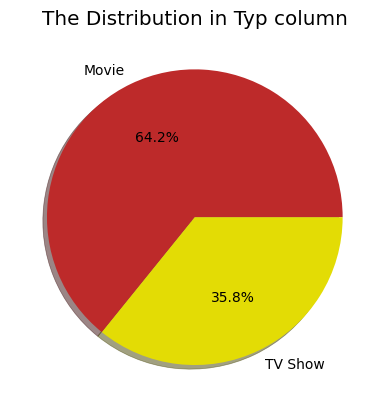

In [ ]:
#Q8
x=df['type'].value_counts()
size=x.values
label=x.index
color=['#bd2a2a','#e3dc05']

plt.pie(size,labels=label,colors=color,autopct='%1.1f%%',shadow=True)
plt.title("The Distribution in Typ column")
plt.show()

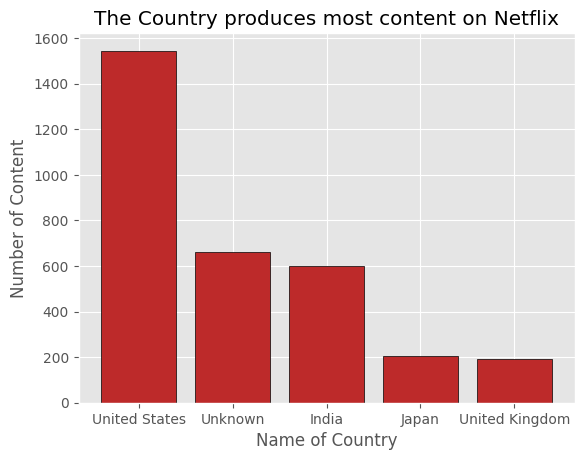

In [ ]:
#Q9

y=df['country'].value_counts().head()
name=y.index
value=y.values

plt.bar(name,value,color='#bd2a2a',edgecolor='black')
plt.title('The Country produces most content on Netflix')
plt.ylabel("Number of Content")
plt.xlabel("Name of Country")
plt.show()

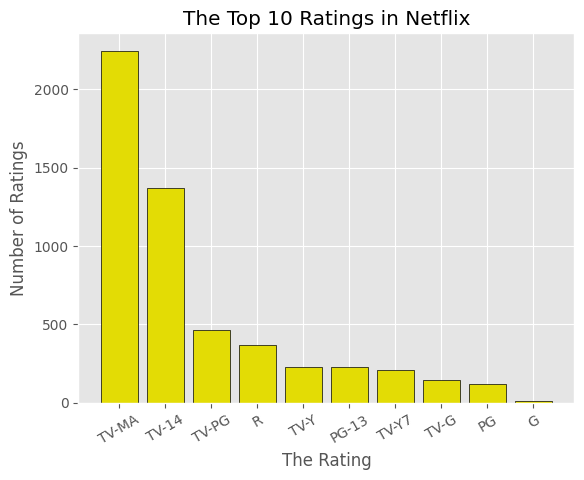

In [ ]:
#Q10

r=df['rating'].value_counts().head(10)
num=r.values
type=r.index

plt.bar(type,num,color='#e3dc05',edgecolor='black')
plt.title('The Top 10 Ratings in Netflix')
plt.xlabel('The Rating')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=30)
plt.show()

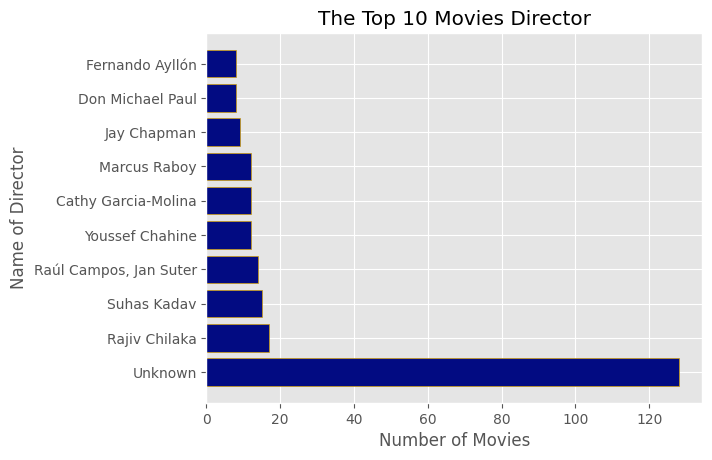

In [ ]:
#Q11
a=df.loc[df['type'].str.contains('Movie'),'director'].value_counts().head(10)
num=a.values
name=a.index

plt.barh(name,num,color="#020b82",edgecolor="#CE9D0B")
plt.title('The Top 10 Movies Director')
plt.ylabel('Name of Director')
plt.xlabel('Number of Movies')
plt.show()


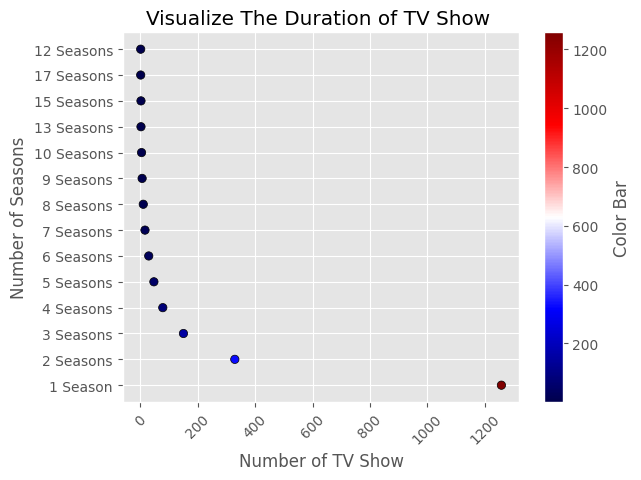

In [ ]:
#Q12
d=df.loc[df['type'].str.contains("TV Show"),'duration'].value_counts()
season=d.index
num=d.values

plt.scatter(num,season,edgecolor='black',c=num,cmap='seismic')
c=plt.colorbar()
c.set_label('Color Bar')
plt.title('Visualize The Duration of TV Show ')
plt.xlabel('Number of TV Show')
plt.ylabel('Number of Seasons')
plt.xticks(rotation=45)
plt.show()


In [ ]:
#Q13
r=df['cast'].str.split(',')
df['actor 1']=r.str[0]
df['actor 2']=r.str[1]
df['actor 2']=df['actor 2'].replace(np.nan,'No more')
df

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,day_added,month_added,year_added,season,actor 1,actor 2
1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Saturday,September,2021,Autumn,Unknown,No more
2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Friday,September,2021,Autumn,Ama Qamata,Khosi Ngema
3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,Friday,September,2021,Autumn,Sami Bouajila,Tracy Gotoas
4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",Friday,September,2021,Autumn,Unknown,No more
5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,Friday,September,2021,Autumn,Mayur More,Jitendra Kumar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,TV Show,Barbie Life in the Dreamhouse,Unknown,"Kate Higgins, Sean Hankinson, Haviland Stillwe...","United States, Canada",2017-07-01,2012.0,TV-Y,1 Season,"Kids' TV, TV Comedies",Join blond icon Barbie and her fabulous friend...,Saturday,July,2017,Summer,Kate Higgins,Sean Hankinson
5394,TV Show,Breakout,Unknown,"Jeanette Aw, Elvin Ng, Zhou Ying, Christopher ...",Unknown,2017-07-01,2010.0,TV-14,1 Season,"International TV Shows, TV Dramas",After losing her family in a suspicious car cr...,Saturday,July,2017,Summer,Jeanette Aw,Elvin Ng
5395,Movie,Hans Teeuwen: Real Rancour,Doesjka van Hoogdalem,Hans Teeuwen,Netherlands,2017-07-01,2018.0,TV-MA,86 min,Stand-Up Comedy,Comedian Hans Teeuwen rebels against political...,Saturday,July,2017,Summer,Hans Teeuwen,No more
5396,TV Show,Intersection,Unknown,"İbrahim Çelikkol, Belçim Bilgin, Alican Yüceso...",Turkey,2017-07-01,2016.0,TV-MA,3 Seasons,"International TV Shows, Romantic TV Shows, TV ...",Two wealthy businessmen with car obsessions cr...,Saturday,July,2017,Summer,İbrahim Çelikkol,Belçim Bilgin


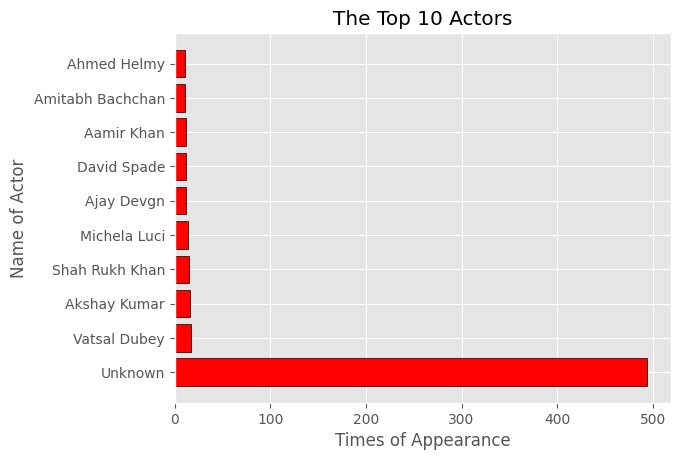

In [ ]:
#Q14
c=df['actor 1'].value_counts().head(10)
name =c.index
app=c.values

plt.barh(name,app,edgecolor='black',color='red')
plt.title('The Top 10 Actors')
plt.xlabel('Times of Appearance')
plt.ylabel('Name of Actor')
plt.show()
